<a href="https://colab.research.google.com/github/springboardmentor148-svg/HealthForecast-AI-Hospital-Readmission-Prediction-Patient-Risk-Intelligence-System/blob/Kamali/processed_data_of_Diabetics_130_US_Hospitals_for_Years_1999_2008.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('diabetic_data.csv')
# STEP 1: LOAD AND MAP HIDDEN MISSING VALUES

In [ ]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
df.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,...,No,No,No,No,No,No,No,No,No,NO


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [ ]:
df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [ ]:
df.replace('?', np.nan, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [ ]:
df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [ ]:
df.isnull().sum()/df.shape[0]*100

,0
encounter_id,0.000000
patient_nbr,0.000000
race,2.233555
gender,0.000000
age,0.000000
weight,96.858479
admission_type_id,0.000000
discharge_disposition_id,0.000000
admission_source_id,0.000000
time_in_hospital,0.000000


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# 1. Define your features (X) and your target label (y)
X = df.drop(columns=['readmitted'])
y = df['readmitted'].map({'NO': 0, '>30': 1, '<30': 1}) # Binary mapping

# 2. Initialize the group splitter
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# 3. Get the split indices based on the patient groups
train_idx, test_idx = next(gss.split(X, y, groups=df['patient_nbr']))

# 4. Generate the final 4 distinct datasets
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [ ]:
# Find the most common value (mode) for race in the training set
train_race_mode = X_train['race'].mode()[0]

# Use .loc to cleanly fill missing values without triggering warnings
X_train.loc[:, 'race'] = X_train['race'].fillna(train_race_mode)
X_test.loc[:, 'race'] = X_test['race'].fillna(train_race_mode)

# Verify the result
print("Missing values in X_train['race'] after imputation:", X_train['race'].isnull().sum())

Missing values in X_train['race'] after imputation: 0


In [ ]:
# Selects columns where the data type is 'object' (text)
text_columns = X_train.select_dtypes(include=['object']).columns.tolist()

print("Columns with text values:")
print(text_columns)

Columns with text values:
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [ ]:
# Loop through the text columns and count their unique values
for col in X_train.select_dtypes(include=['object']).columns:
    print(f"{col}: {X_train[col].nunique()} unique text values")

race: 5 unique text values
gender: 3 unique text values
age: 10 unique text values
weight: 9 unique text values
payer_code: 16 unique text values
medical_specialty: 71 unique text values
diag_1: 700 unique text values
diag_2: 719 unique text values
diag_3: 754 unique text values
max_glu_serum: 3 unique text values
A1Cresult: 3 unique text values
metformin: 4 unique text values
repaglinide: 4 unique text values
nateglinide: 4 unique text values
chlorpropamide: 4 unique text values
glimepiride: 4 unique text values
acetohexamide: 1 unique text values
glipizide: 4 unique text values
glyburide: 4 unique text values
tolbutamide: 2 unique text values
pioglitazone: 4 unique text values
rosiglitazone: 4 unique text values
acarbose: 4 unique text values
miglitol: 4 unique text values
troglitazone: 2 unique text values
tolazamide: 2 unique text values
examide: 1 unique text values
citoglipton: 1 unique text values
insulin: 4 unique text values
glyburide-metformin: 4 unique text values
glipizide-

In [ ]:
# Drop high-missing or low-value columns instantly
cols_to_drop = ['weight', 'payer_code', 'medical_specialty']
X_train = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test = X_test.drop(columns=cols_to_drop, errors='ignore')

In [ ]:
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

In [ ]:
# 1. Define every single negligible, missing, and zero-variance column
all_cols_to_drop = [
    'weight', 'payer_code', 'medical_specialty', # High missing data
    'encounter_id', 'patient_nbr',              # System IDs
    'acetohexamide', 'examide', 'citoglipton', 'metformin-pioglitazone', # Zero variance (1 value)
    'troglitazone', 'tolbutamide', 'tolazamide',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone' # Extremely rare drugs
]

# 2. Drop them safely from both sets
X_train = X_train.drop(columns=all_cols_to_drop, errors='ignore')
X_test = X_test.drop(columns=all_cols_to_drop, errors='ignore')

# 3. Check what text columns are left
remaining_text_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print("Cleaned text columns left to encode:\n", remaining_text_cols)

Cleaned text columns left to encode:
 ['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'change', 'diabetesMed']


In [ ]:
# Selects columns where the data type is 'object' (text)
text_columns = X_train.select_dtypes(include=['object']).columns.tolist()

print("Columns with text values:")
print(text_columns)

Columns with text values:
['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'change', 'diabetesMed']


In [ ]:
import pandas as pd

def map_icd9_to_category(code):
    if pd.isnull(code) or code == '?':
        return 'Unknown'
    if str(code).startswith(('E', 'V')):
        return 'Other'
    try:
        val = float(code)
        if 390 <= val <= 459 or val == 785:
            return 'Circulatory'
        elif 460 <= val <= 519 or val == 786:
            return 'Respiratory'
        elif 520 <= val <= 579 or val == 787:
            return 'Digestive'
        elif int(val) == 250:
            return 'Diabetes'
        elif 800 <= val <= 999:
            return 'Injury'
        elif 710 <= val <= 739:
            return 'Musculoskeletal'
        elif 580 <= val <= 629 or val == 788:
            return 'Genitourinary'
        else:
            return 'Other'
    except ValueError:
        return 'Other'

# Apply the mapping safely using .loc
for col in ['diag_1', 'diag_2', 'diag_3']:
    X_train.loc[:, col] = X_train[col].apply(map_icd9_to_category)
    X_test.loc[:, col] = X_test[col].apply(map_icd9_to_category)

In [ ]:
# Automatically find all remaining text columns
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Convert text to binary numbers
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns so Train and Test are identical shapes
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

print(f"Text encoding complete! New features count: {X_train_encoded.shape[1]}")

Text encoding complete! New features count: 96


In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                'num_medications', 'number_outpatient', 'number_emergency',
                'number_inpatient', 'number_diagnoses']

scaler = StandardScaler()

# Scale train and transform test safely
X_train_encoded[numeric_cols] = scaler.fit_transform(X_train_encoded[numeric_cols])
X_test_encoded[numeric_cols] = scaler.transform(X_test_encoded[numeric_cols])

print("--- ALL PREPROCESSING COMPLETED ---")

--- ALL PREPROCESSING COMPLETED ---


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [ ]:
print("Missing values in Train:", X_train_encoded.isnull().sum().sum())
print("Missing values in Test:", X_test_encoded.isnull().sum().sum())
print("Train Columns match Test Columns perfectly:", list(X_train_encoded.columns) == list(X_test_encoded.columns))
print("Final Dataset Shapes:", X_train_encoded.shape, X_test_encoded.shape)

Missing values in Train: 0
Missing values in Test: 0
Train Columns match Test Columns perfectly: True
Final Dataset Shapes: (81613, 96) (20153, 96)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# ==========================================
# STEP 1: INITIALIZE AND TRAIN THE BASELINE MODEL
# ==========================================
# class_weight='balanced' ensures the model treats catching a readmission with high priority
baseline_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

print("Training the baseline model on your 72 preprocessed features...")
baseline_model.fit(X_train_encoded, y_train)

# ==========================================
# STEP 2: GENERATE REAL-WORLD PREDICTIONS
# ==========================================
# 1. Hard classification flags (0 or 1)
y_pred_base = baseline_model.predict(X_test_encoded)

# 2. Continuous probability risk scores (0.0 to 1.0) for real-time tracking
y_pred_base_proba = baseline_model.predict_proba(X_test_encoded)[:, 1]

# ==========================================
# STEP 3: OUTPUT PERFORMANCE BENCHMARKS
# ==========================================
print("\n=== BASELINE MODEL TRAINING COMPLETE ===")
print(f"Airtight Test ROC-AUC Score: {roc_auc_score(y_test, y_pred_base_proba):.4f}")
print("\n📊 Clinical Classification Report:")
print(classification_report(y_test, y_pred_base, target_names=['No Readmit', 'Readmitted']))

Training the baseline model on your 72 preprocessed features...

=== BASELINE MODEL TRAINING COMPLETE ===
Airtight Test ROC-AUC Score: 0.6611

📊 Clinical Classification Report:
              precision    recall  f1-score   support

  No Readmit       0.86      0.01      0.02     11014
  Readmitted       0.46      1.00      0.63      9139

    accuracy                           0.46     20153
   macro avg       0.66      0.50      0.32     20153
weighted avg       0.68      0.46      0.29     20153



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize and train Random Forest
# We set class_weight='balanced' but cap max_depth=12 so it doesn't overfit the noise
rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1)

print("Training the Random Forest Council of Experts on 72 features...")
rf_model.fit(X_train_encoded, y_train)

# 2. Predict on test data
y_pred_rf = rf_model.predict(X_test_encoded)
y_pred_rf_proba = rf_model.predict_proba(X_test_encoded)[:, 1]

# 3. Print Results
print("\n=== 2. RANDOM FOREST PERFORMANCE MATRICES ===")
print(f"Random Forest ROC-AUC Score: {roc_auc_score(y_test, y_pred_rf_proba):.4f}\n")
print(classification_report(y_test, y_pred_rf, target_names=['No Readmit', 'Readmitted']))

Training the Random Forest Council of Experts on 72 features...

=== 2. RANDOM FOREST PERFORMANCE MATRICES ===
Random Forest ROC-AUC Score: 0.6874

              precision    recall  f1-score   support

  No Readmit       0.67      0.66      0.66     11014
  Readmitted       0.60      0.61      0.60      9139

    accuracy                           0.64     20153
   macro avg       0.63      0.63      0.63     20153
weighted avg       0.64      0.64      0.64     20153



In [ ]:
import re
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# =======================================================
# STEP 1: CLEAN UP SPECIAL CHARACTERS FROM COLUMN NAMES FOR XGBOOST
# =======================================================
# XGBoost C++ backend does not allow [, ], or < in feature names.
regex = re.compile(r"\[|\]|<", re.IGNORECASE)

# Rename the columns dynamically in both datasets
X_train_encoded.columns = [regex.sub("_", col) if regex.search(col) else col for col in X_train_encoded.columns]
X_test_encoded.columns = [regex.sub("_", col) if regex.search(col) else col for col in X_test_encoded.columns]

# =======================================================
# STEP 2: INITIALIZE AND TRAIN XGBOOST
# =======================================================
# Calculating ratio of negative to positive cases dynamically for scale_pos_weight
ratio = (len(y_train) - sum(y_train)) / sum(y_train)

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss'
)

print("Training the XGBoost engine safely without forbidden characters...")
xgb_model.fit(X_train_encoded, y_train)

# =======================================================
# STEP 3: PREDICT AND METRIC ANALYSIS
# =======================================================
y_pred_xgb = xgb_model.predict(X_test_encoded)
y_pred_xgb_proba = xgb_model.predict_proba(X_test_encoded)[:, 1]

print("\n=== XGBOOST MODEL PERFORMANCE ===")
print(f"XGBoost Test ROC-AUC Score: {roc_auc_score(y_test, y_pred_xgb_proba):.4f}\n")
print(classification_report(y_test, y_pred_xgb, target_names=['No Readmit', 'Readmitted']))

Training the XGBoost engine safely without forbidden characters...

=== XGBOOST MODEL PERFORMANCE ===
XGBoost Test ROC-AUC Score: 0.6930

              precision    recall  f1-score   support

  No Readmit       0.69      0.60      0.64     11014
  Readmitted       0.58      0.67      0.62      9139

    accuracy                           0.63     20153
   macro avg       0.63      0.63      0.63     20153
weighted avg       0.64      0.63      0.63     20153



In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

# 1. Define the search space (the combinations of knobs we want to test)
param_distributions = {
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [150, 250, 400],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# 2. Re-calculate your base ratio for balance consistency
ratio = (len(y_train) - sum(y_train)) / sum(y_train)

# 3. Initialize the base classifier
base_xgb = XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss')

# 4. Set up the automated search engine targeting the highest ROC-AUC
# n_iter=7 means it will randomly test 7 distinct configurations to complete efficiently
xgb_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_distributions,
    n_iter=7,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Searching for the absolute best parameter configuration...")
xgb_search.fit(X_train_encoded, y_train)

# =======================================================
# EVALUATING THE OPTIMIZED MACHINE LEARNING ENGINE
# =======================================================
best_xgb_model = xgb_search.best_estimator_
y_opt_proba = best_xgb_model.predict_proba(X_test_encoded)[:, 1]
y_opt_pred = best_xgb_model.predict(X_test_encoded)

print("\n🏆 OPTIMIZATION COMPLETE 🏆")
print(f"Best Parameters Found: {xgb_search.best_params_}")
print(f"New Optimized ROC-AUC Score: {roc_auc_score(y_test, y_opt_proba):.4f}\n")
print(classification_report(y_test, y_opt_pred, target_names=['No Readmit', 'Readmitted']))

Searching for the absolute best parameter configuration...
Fitting 3 folds for each of 7 candidates, totalling 21 fits

🏆 OPTIMIZATION COMPLETE 🏆
Best Parameters Found: {'subsample': 0.8, 'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
New Optimized ROC-AUC Score: 0.6954

              precision    recall  f1-score   support

  No Readmit       0.67      0.67      0.67     11014
  Readmitted       0.60      0.60      0.60      9139

    accuracy                           0.64     20153
   macro avg       0.64      0.64      0.64     20153
weighted avg       0.64      0.64      0.64     20153



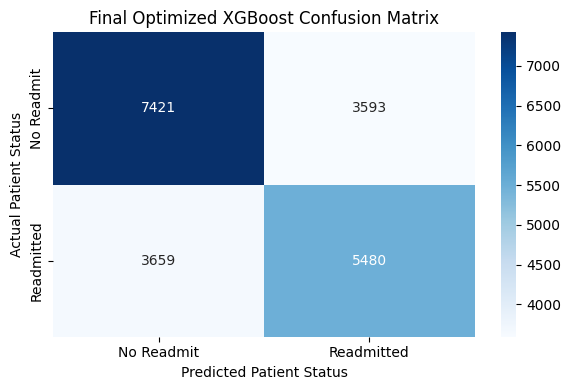

/tmp/ipykernel_4154/1031051843.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_15_features, palette='viridis')


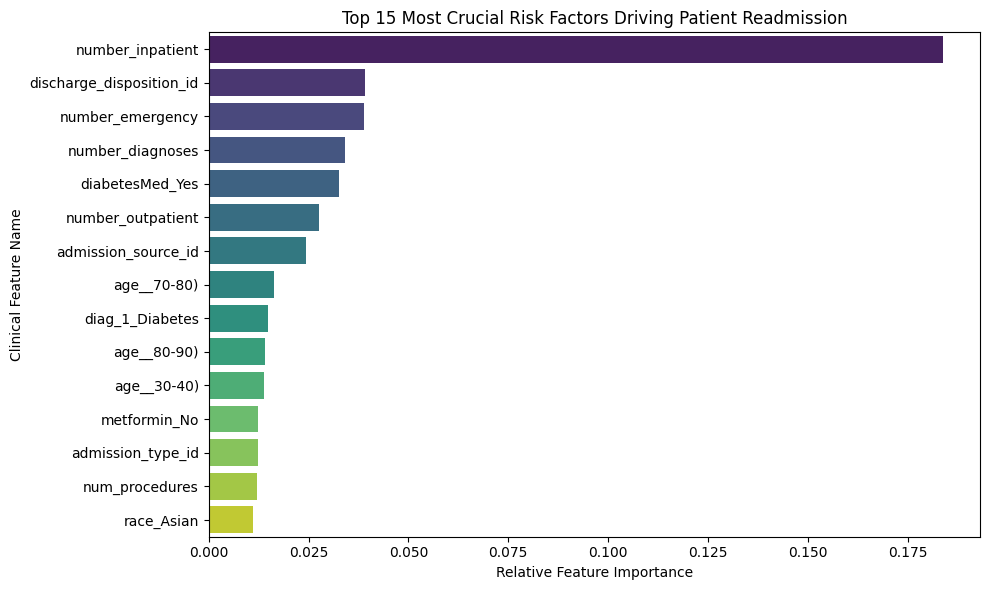

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

# =======================================================
# VISUAL 1: THE REBALANCED CONFUSION MATRIX
# =======================================================
cm = confusion_matrix(y_test, y_opt_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Readmit', 'Readmitted'],
            yticklabels=['No Readmit', 'Readmitted'])
plt.ylabel('Actual Patient Status')
plt.xlabel('Predicted Patient Status')
plt.title('Final Optimized XGBoost Confusion Matrix')
plt.tight_layout()
plt.show()

# =======================================================
# VISUAL 2: CLINICAL FEATURE IMPORTANCE
# =======================================================
importances = best_xgb_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': X_train_encoded.columns, 'Importance': importances})

# Sort and extract the top 15 highest-value clinical weights
top_15_features = feature_imp_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_15_features, palette='viridis')
plt.title('Top 15 Most Crucial Risk Factors Driving Patient Readmission')
plt.xlabel('Relative Feature Importance')
plt.ylabel('Clinical Feature Name')
plt.tight_layout()
plt.show()

In [ ]:
import joblib

# Save the trained model
joblib.dump(best_xgb_model, 'optimized_xgb_model.pkl')

# Save the scaler so new patient data can be normalized identically
joblib.dump(scaler, 'numerical_scaler.pkl')

print("Model and Scaler successfully saved as deployment assets!")

Model and Scaler successfully saved as deployment assets!
